# MIPAR Feature Measurement Analysis: GOO220\_52 vs GOO220\_53

Compares M23C6, MX ZPhase, and Laves precipitate populations across two material states
measured by MIPAR image analysis.

**Workflow**
1. Preview the raw data with `stamp.io.load_mipar_features`.
2. Run the per-FOV statistics pipeline for each phase via `stamp.pipeline.run_mipar`.
3. Box plots — individual phase plots and a combined multi-panel figure.
4. Summary table — mean of per-FOV means and standard deviations for ECD.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import stamp.pipeline as pipeline
from stamp.io import load_mipar_features
from stamp.pipeline import run_mipar
from stamp.plot import _apply_style
from stamp.pipeline import _STATE_COLORS

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("notebooks/data") if Path.cwd().name != "notebooks" else Path("data")
OUT_DIR  = DATA_DIR / "GOO220_mipar"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ECD_COL  = "Equivalent Diameter (um)"
AREA_COL = "Area (um^2)"

FILES = {
    "GOO220_51": DATA_DIR / "GOO220_51_FeatureMeas.csv",
    "GOO220_52": DATA_DIR / "GOO220_52_FeatureMeas.csv",
    "GOO220_53": DATA_DIR / "GOO220_53_FeatureMeas.csv",
}

PHASES = ["M23C6", "MX ZPhase", "Laves"]

In [2]:
import os; print(os.getcwd())
DATA_DIR.exists()
FILES

C:\Users\westraadt.1\Repos\STAMP\notebooks


{'GOO220_51': WindowsPath('data/GOO220_51_FeatureMeas.csv'),
 'GOO220_52': WindowsPath('data/GOO220_52_FeatureMeas.csv'),
 'GOO220_53': WindowsPath('data/GOO220_53_FeatureMeas.csv')}

## 1. Preview raw data

In [3]:
for state, path in FILES.items():
    df = load_mipar_features(path)
    n_fovs   = df["Image"].nunique()
    n_feat   = len(df)
    phases   = sorted(df["Layer"].unique())
    print(f"{state}: {n_feat:,} features across {n_fovs} FOVs | phases: {phases}")

print()
display(load_mipar_features(FILES["GOO220_51"]).head(4))

GOO220_51: 8,812 features across 10 FOVs | phases: ['Laves', 'M23C6', 'MX ZPhase']
GOO220_52: 10,911 features across 10 FOVs | phases: ['Laves', 'M23C6', 'MX ZPhase']
GOO220_53: 9,884 features across 10 FOVs | phases: ['Laves', 'M23C6', 'MX ZPhase']



,Image,Layer,Feature,Area (um^2),Equivalent Diameter (um),CentroidX (um),CentroidY (um),Average Neighbor Distance (um)
0,T3_Mode2-GOO220_51_001_processed.tif,M23C6,1,0.001113,0.037644,0.050309,9.479363,2.701132
1,T3_Mode2-GOO220_51_001_processed.tif,M23C6,2,0.015695,0.141364,0.115385,0.861511,3.544124
2,T3_Mode2-GOO220_51_001_processed.tif,M23C6,3,0.001283,0.040423,0.058274,12.925024,1.403527
3,T3_Mode2-GOO220_51_001_processed.tif,M23C6,4,0.004123,0.072450,0.083414,13.260662,0.352284


## 2. Run per-FOV ECD pipeline for each phase

`run_mipar` reads each MIPAR CSV, filters to one phase, groups rows by FOV image,
and computes per-FOV statistics (arithmetic mean, geometric mean, median, CIs).

In [4]:
results_ecd = {}
for phase in PHASES:
    results_ecd[phase] = run_mipar(
        FILES,
        measurement=ECD_COL,
        unit="µm",
        phase=phase,
        label=f"{phase} ECD",
        metric="amean",
    )
    n_fovs = len(results_ecd[phase].summary)
    print(f"{phase}: {n_fovs} FOV records ({n_fovs // len(FILES)} per state)")

print()
print("── Per-FOV summary (M23C6) ──")
display(
    results_ecd["M23C6"].summary[
        ["state", "fov", "n", "amean", "amean_std", "gmean", "median"]
    ].round(4)
)

M23C6: 30 FOV records (10 per state)
MX ZPhase: 30 FOV records (10 per state)
Laves: 30 FOV records (10 per state)

── Per-FOV summary (M23C6) ──


,state,fov,n,amean,amean_std,gmean,median
0,GOO220_51,T3_Mode2-GOO220_51_001_processed,651,0.1232,0.0911,0.0875,0.1034
1,GOO220_51,T3_Mode2-GOO220_51_002_processed,765,0.1184,0.0782,0.0905,0.1048
2,GOO220_51,T3_Mode2-GOO220_51_003_processed,697,0.1274,0.0883,0.0965,0.1130
3,GOO220_51,T3_Mode2-GOO220_51_004_processed,813,0.1168,0.0826,0.0845,0.0989
4,GOO220_51,T3_Mode2-GOO220_51_006_processed,707,0.1219,0.0847,0.0926,0.1008
5,GOO220_51,T3_Mode2-GOO220_51_007_processed,478,0.1418,0.1142,0.1001,0.1162
6,GOO220_51,T3_Mode2-GOO220_51_008_processed,653,0.1307,0.0901,0.0971,0.1148
7,GOO220_51,T3_Mode2-GOO220_51_009_processed,713,0.1271,0.0832,0.1002,0.1101
8,GOO220_51,T3_Mode2-GOO220_51_010_processed,654,0.1344,0.0873,0.1030,0.1177
9,GOO220_51,T3_Mode2-GOO220_51_011_processed,706,0.1266,0.0858,0.0975,0.1080


## 3. Box plots — one per phase

Each box spans the IQR of the per-FOV arithmetic means; individual FOV points are overlaid.

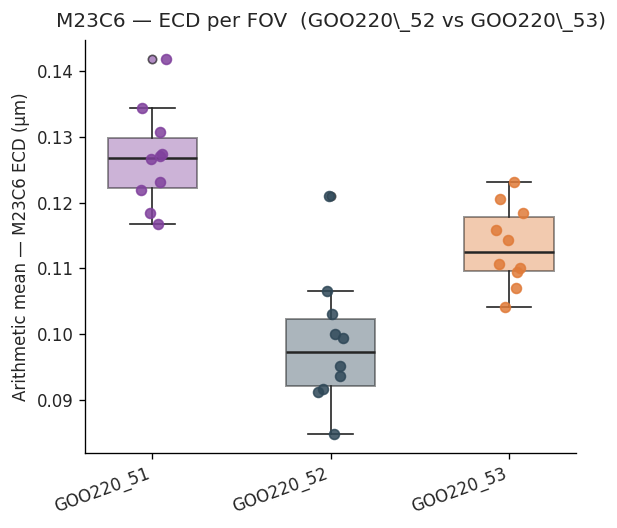

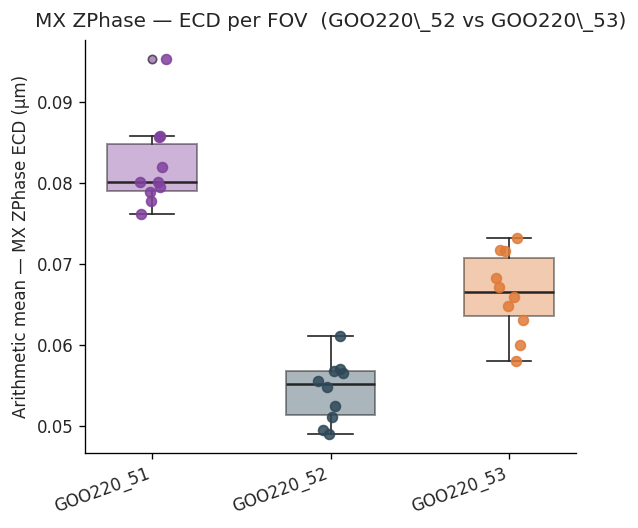

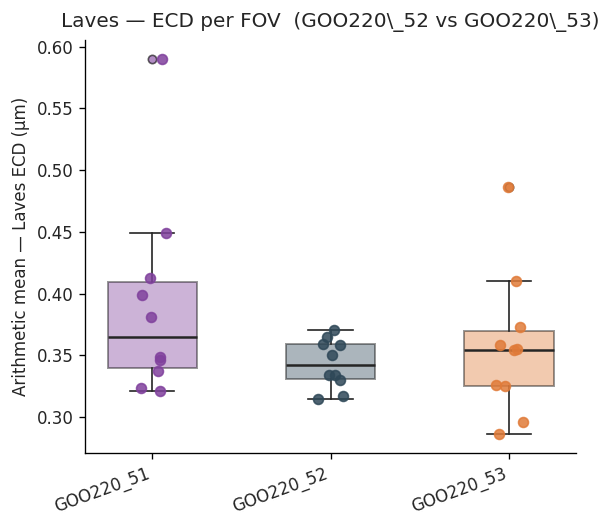

In [5]:
for phase in PHASES:
    fig = pipeline.boxplot(
        results_ecd[phase],
        metric="amean",
        output_path=OUT_DIR / f"boxplot_ecd_{phase.replace(' ', '_')}.png",
        figsize=(5, 4.5),
    )
    fig.axes[0].set_title(
        f"{phase} — ECD per FOV  (GOO220\_52 vs GOO220\_53)", pad=8
    )
    fig.tight_layout()
    plt.show()

## 4. Combined multi-panel ECD figure

All three phases side-by-side for direct publication comparison.

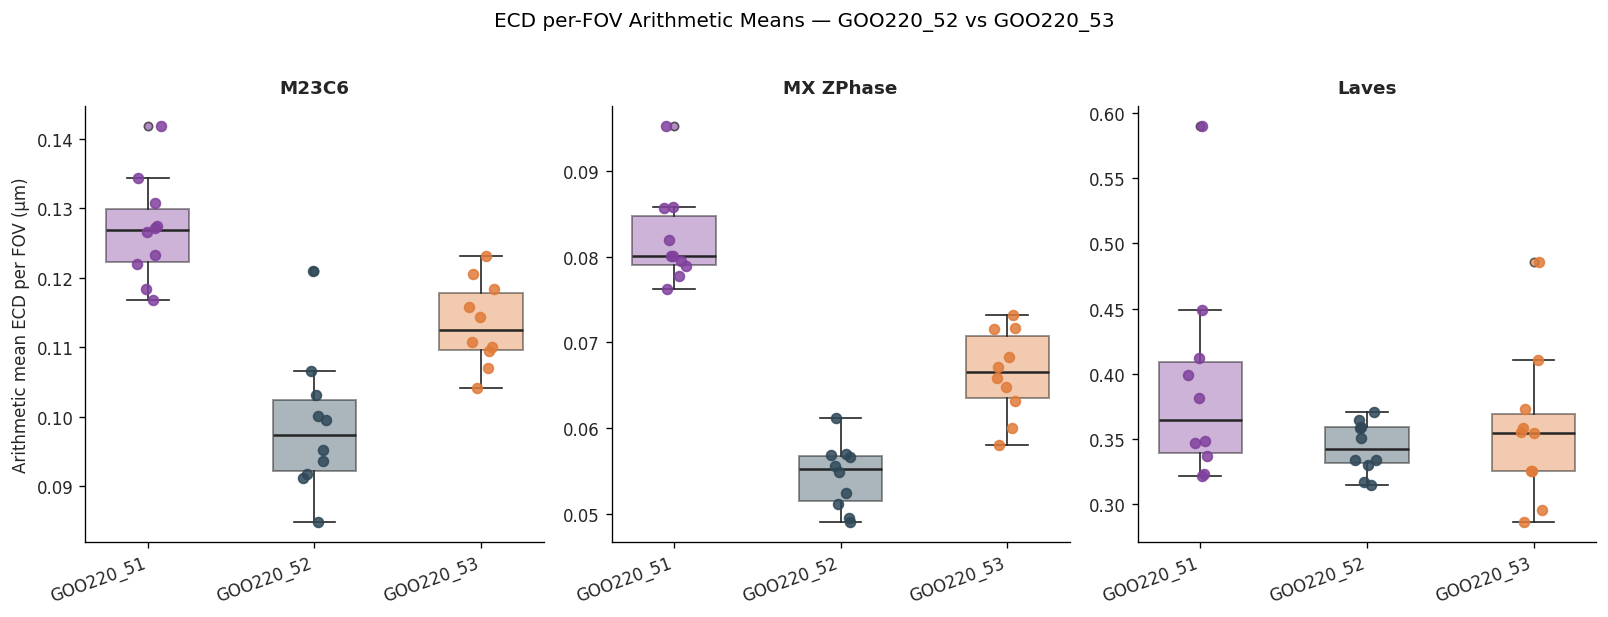

In [6]:
fig, axes = plt.subplots(1, len(PHASES), figsize=(4.5 * len(PHASES), 5), sharey=False)

rng = np.random.default_rng(42)

for ax, phase in zip(axes, PHASES):
    result = results_ecd[phase]
    summary = result.summary

    for i, sr in enumerate(result.states):
        vals = summary[summary["state"] == sr.name]["amean"].values
        color = _STATE_COLORS[i % len(_STATE_COLORS)]
        pos = i + 1

        ax.boxplot(
            vals,
            positions=[pos],
            widths=0.5,
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.4, linewidth=1.2),
            medianprops=dict(color="#252525", linewidth=1.5),
            whiskerprops=dict(color="#252525", linewidth=1.0),
            capprops=dict(color="#252525", linewidth=1.0),
            flierprops=dict(marker="o", markerfacecolor=color, markersize=5, alpha=0.6),
            manage_ticks=False,
        )
        jitter = rng.uniform(-0.08, 0.08, len(vals))
        ax.scatter(pos + jitter, vals, color=color, alpha=0.85, s=35, zorder=3,
                   label=sr.name if phase == PHASES[0] else None)

    ax.set_xticks(range(1, len(result.states) + 1))
    ax.set_xticklabels([sr.name for sr in result.states], rotation=20, ha="right")
    ax.set_title(phase, fontsize=11, fontweight="bold", pad=8)
    _apply_style(ax)

    if ax is axes[0]:
        ax.set_ylabel("Arithmetic mean ECD per FOV (µm)", fontsize=10)

fig.suptitle(
    "ECD per-FOV Arithmetic Means — GOO220_52 vs GOO220_53",
    fontsize=12, y=1.02,
)
fig.tight_layout()
fig.savefig(OUT_DIR / "boxplot_ecd_combined.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Summary table — mean of per-FOV means and ECD standard deviations

Each row is one (material state × phase) combination.  
`Mean ECD` is the mean of the per-FOV arithmetic means; `Std ECD` is their standard deviation.

In [7]:
rows = []
for phase in PHASES:
    s = results_ecd[phase].summary
    for state_name, grp in s.groupby("state"):
        rows.append({
            "State":         state_name,
            "Phase":         phase,
            "N FOVs":        len(grp),
            "N Features":    int(grp["n"].sum()),
            "Mean ECD (µm)": grp["amean"].mean(),
            "Std ECD (µm)":  grp["amean"].std(),
            "Min ECD (µm)":  grp["amean"].min(),
            "Max ECD (µm)":  grp["amean"].max(),
        })

summary_df = pd.DataFrame(rows).round(4)
display(summary_df)

out_path = OUT_DIR / "summary_ecd_by_state_phase.csv"
summary_df.to_csv(out_path, index=False)
print(f"\nSaved → {out_path}")

,State,Phase,N FOVs,N Features,Mean ECD (µm),Std ECD (µm),Min ECD (µm),Max ECD (µm)
0,GOO220_51,M23C6,10,6837,0.1268,0.0075,0.1168,0.1418
1,GOO220_52,M23C6,10,8605,0.0987,0.0101,0.0848,0.1210
2,GOO220_53,M23C6,10,7797,0.1134,0.0061,0.1042,0.1231
3,GOO220_51,MX ZPhase,10,1843,0.0821,0.0056,0.0762,0.0952
4,GOO220_52,MX ZPhase,10,2159,0.0544,0.0038,0.0490,0.0611
5,GOO220_53,MX ZPhase,10,1986,0.0664,0.0050,0.0581,0.0732
6,GOO220_51,Laves,10,132,0.3909,0.0814,0.3213,0.5899
7,GOO220_52,Laves,10,147,0.3433,0.0201,0.3144,0.3708
8,GOO220_53,Laves,10,101,0.3570,0.0583,0.2860,0.4860



Saved → data\GOO220_mipar\summary_ecd_by_state_phase.csv


## 6. ECD comparison — pivoted view

Both states on the same row per phase for side-by-side comparison.

In [8]:
pivot = summary_df.pivot(
    index="Phase",
    columns="State",
    values=["Mean ECD (µm)", "Std ECD (µm)", "N Features"],
)
pivot.columns = [f"{metric} | {state}" for metric, state in pivot.columns]
pivot = pivot.reset_index().round(4)
display(pivot)

,Phase,Mean ECD (µm) | GOO220_51,Mean ECD (µm) | GOO220_52,Mean ECD (µm) | GOO220_53,Std ECD (µm) | GOO220_51,Std ECD (µm) | GOO220_52,Std ECD (µm) | GOO220_53,N Features | GOO220_51,N Features | GOO220_52,N Features | GOO220_53
0,Laves,0.3909,0.3433,0.3570,0.0814,0.0201,0.0583,132.0,147.0,101.0
1,M23C6,0.1268,0.0987,0.1134,0.0075,0.0101,0.0061,6837.0,8605.0,7797.0
2,MX ZPhase,0.0821,0.0544,0.0664,0.0056,0.0038,0.0050,1843.0,2159.0,1986.0
